# Pneumonia Chest X-Ray Classifier -- rigorous rebuild

This notebook trains and evaluates the binary Normal-vs-Pneumonia classifier
at the scale the original course report claimed (the full 5,863-image
Kermany chest X-ray dataset), fixing the gap where the original notebook
only ever trained on ~44 hand-picked images and evaluated on 34.

**What this notebook does:**
1. Installs dependencies and reconstructs the `pneumonia_cnn` package (same
   code as `../src/pneumonia_cnn/`, embedded here so this notebook is
   self-contained on a fresh Colab runtime).
2. Downloads the real dataset via the Kaggle API (you'll need your own
   Kaggle API token -- see Step 1 below).
3. Trains 3 seeds, evaluates on the full held-out 624-image test set with
   bootstrap confidence intervals, and generates Grad-CAM explainability
   overlays.
4. Zips up all results for download.

**Before running:** Runtime -> Change runtime type -> select a GPU.


## Step 0: Install dependencies and reconstruct the package

Colab already ships TensorFlow, scikit-learn, matplotlib, and Pillow. We
only need PyYAML and the Kaggle CLI.

In [ ]:
!pip install -q pyyaml kaggle

In [ ]:
import os
os.makedirs("pneumonia_cnn/federated", exist_ok=True)
os.makedirs("configs", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("directories ready")

directories ready


The next cells recreate `pneumonia_cnn/` file-by-file -- identical to `../src/pneumonia_cnn/` in the repo.

In [ ]:
%%writefile pneumonia_cnn/__init__.py
"""Pneumonia chest X-ray classification pipeline.

Rebuilt to actually match the original course report's claims: trained and
evaluated at the scale the report describes (thousands of images, not
dozens), with rigor the original notebook skipped (proper held-out test set,
multi-seed evaluation, confidence intervals).
"""

__version__ = "0.1.0"


Writing pneumonia_cnn/__init__.py


In [ ]:
%%writefile pneumonia_cnn/config.py
"""Central config for the training pipeline.

Everything that differs between the binary run (this pass) and a future
multiclass run (Normal/Bacterial/Viral/COVID) lives here. Switching tasks
later should mean editing a YAML file, not touching data.py/model.py/train.py.
"""
from __future__ import annotations

import dataclasses
from pathlib import Path
from typing import List

import yaml


@dataclasses.dataclass
class Config:
    # --- task definition ---
    class_names: List[str]              # e.g. ["NORMAL", "PNEUMONIA"]
    data_root: str                      # dir containing train/, val/, test/ subdirs,
                                         # each with one subfolder per class name

    # --- image / model ---
    img_size: int = 224
    backbone: str = "vgg16"             # vgg16 today; model.py can add more
    dense_units: int = 64
    dropout: float = 0.5
    pretrained: bool = True             # False = random init, no ImageNet weight
                                         # download (used by the offline smoke test)

    # --- training ---
    batch_size: int = 32
    epochs: int = 15
    init_lr: float = 1e-3
    val_fraction: float = 0.10          # fraction of pooled train+val held for validation
    seeds: List[int] = dataclasses.field(default_factory=lambda: [42, 43, 44])
    use_class_weights: bool = True
    early_stopping_patience: int = 4

    # --- fine-tuning (phase 2, optional) ---
    # Phase 1 always trains only the dense head on a frozen backbone. If
    # fine_tune is set, phase 2 unfreezes the backbone's last fine_tune_layers
    # layers and continues training at a much lower LR. See model.py's
    # unfreeze_top_layers() and train.py's two-phase train_one_seed().
    fine_tune: bool = False
    fine_tune_layers: int = 4           # trailing backbone layers to unfreeze (~ last conv block for VGG16)
    fine_tune_epochs: int = 6
    fine_tune_lr: float = 1e-5

    # --- corner-masking ablation (optional) ---
    # Zeroes out corner squares of the image before it ever reaches the
    # model, to test whether accuracy depends on printed laterality markers
    # (e.g. the "R" marker Grad-CAM surfaced attention on) rather than lung
    # tissue. Applied identically to train/val/test when enabled, so the
    # comparison against an unmasked run is apples-to-apples. See data.py's
    # make_corner_mask().
    mask_corners: bool = False
    mask_corner_frac: float = 0.12      # fraction of image width/height masked in each of the 4 corners

    # --- output ---
    results_dir: str = "results"

    @property
    def num_classes(self) -> int:
        return len(self.class_names)

    @classmethod
    def from_yaml(cls, path: str | Path) -> "Config":
        with open(path, "r", encoding="utf-8") as f:
            raw = yaml.safe_load(f)
        return cls(**raw)

    @property
    def train_dir(self) -> str:
        return str(Path(self.data_root) / "train")

    @property
    def val_dir(self) -> str:
        """The dataset's official val/ split -- pooled into train, not used standalone.

        The Kaggle chest_xray dataset ships only 16 images here, which is why
        the original project's rigor was thin. data.py pools this into the
        train pool and re-splits properly instead of trusting it as-is.
        """
        return str(Path(self.data_root) / "val")

    @property
    def test_dir(self) -> str:
        return str(Path(self.data_root) / "test")


Writing pneumonia_cnn/config.py


In [ ]:
%%writefile pneumonia_cnn/data.py
"""Data loading and splitting.

Fixes the two concrete data-handling gaps found in the original project:
  1. Trains on the full class-subfolder directories the report claims to use,
     not a hand-picked 25/25 sample.
  2. The Kaggle chest_xray dataset's official val/ split is only 16 images
     (a known flaw in that dataset). We pool train/ + val/ and re-split
     stratified, keeping test/ completely untouched as the held-out set.
"""
from __future__ import annotations

import dataclasses
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

from .config import Config

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


def list_pairs(directory: str, class_names: List[str]) -> List[Tuple[str, int]]:
    """Every (filepath, label_index) under directory/<class_name>/ for each class."""
    pairs: List[Tuple[str, int]] = []
    root = Path(directory)
    for idx, cls in enumerate(class_names):
        cls_dir = root / cls
        if not cls_dir.is_dir():
            continue
        for p in sorted(cls_dir.iterdir()):
            if p.suffix.lower() in IMG_EXTENSIONS:
                pairs.append((str(p), idx))
    return pairs


def make_corner_mask(img_size: int, frac: float) -> np.ndarray:
    """(img_size, img_size, 1) array of 1s with `frac`-sized squares zeroed
    out in all 4 corners -- removes printed laterality markers (e.g. the
    "R" marker Grad-CAM surfaced attention on) from the image before it
    reaches the model, without needing to know which corner a given image
    uses. Multiply elementwise against a normalized [0,1] image.
    """
    mask = np.ones((img_size, img_size, 1), dtype=np.float32)
    c = max(1, int(round(img_size * frac)))
    mask[:c, :c, :] = 0.0   # top-left
    mask[:c, -c:, :] = 0.0  # top-right
    mask[-c:, :c, :] = 0.0  # bottom-left
    mask[-c:, -c:, :] = 0.0  # bottom-right
    return mask


def _compute_class_weights(pairs: List[Tuple[str, int]], num_classes: int) -> Dict[int, float]:
    counts = np.zeros(num_classes, dtype=np.float64)
    for _, label in pairs:
        counts[label] += 1
    counts = np.maximum(counts, 1)  # avoid div-by-zero for an absent class
    total = counts.sum()
    weights = total / (num_classes * counts)
    return {i: float(w) for i, w in enumerate(weights)}


def _make_tf_dataset(
    pairs: List[Tuple[str, int]],
    img_size: int,
    batch_size: int,
    augment: bool,
    shuffle: bool,
    seed: int,
    mask_corners: bool = False,
    mask_corner_frac: float = 0.12,
) -> tf.data.Dataset:
    paths = [p for p, _ in pairs]
    labels = [label for _, label in pairs]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=max(len(paths), 1), seed=seed, reshuffle_each_iteration=True)

    corner_mask_tensor = tf.constant(make_corner_mask(img_size, mask_corner_frac)) if mask_corners else None

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [img_size, img_size])
        img = tf.cast(img, tf.float32) / 255.0
        if corner_mask_tensor is not None:
            img = img * corner_mask_tensor
        return img, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        augmenter = tf.keras.Sequential(
            [
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.04),  # ~+/-15 degrees
                tf.keras.layers.RandomZoom(0.1),
            ]
        )
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

    return ds.prefetch(tf.data.AUTOTUNE)


@dataclasses.dataclass
class Datasets:
    train: tf.data.Dataset
    val: tf.data.Dataset
    test: Optional[tf.data.Dataset]
    class_weights: Optional[Dict[int, float]]
    train_count: int
    val_count: int
    test_count: int
    test_labels: List[int]  # true labels in the same order the test dataset yields batches


def build_datasets(config: Config, seed: int) -> Datasets:
    """Pool train/+val/, stratified re-split, load held-out test/ separately."""
    train_pairs = list_pairs(config.train_dir, config.class_names)
    val_pairs = list_pairs(config.val_dir, config.class_names)
    pooled = train_pairs + val_pairs

    if not pooled:
        raise FileNotFoundError(
            f"No images found under {config.train_dir!r} or {config.val_dir!r}. "
            f"Expected one subfolder per class name in {config.class_names}."
        )

    labels = [label for _, label in pooled]
    train_split, val_split = train_test_split(
        pooled,
        test_size=config.val_fraction,
        random_state=seed,
        stratify=labels,
    )

    test_pairs = list_pairs(config.test_dir, config.class_names)

    class_weights = _compute_class_weights(train_split, config.num_classes) if config.use_class_weights else None

    mask_kwargs = {"mask_corners": config.mask_corners, "mask_corner_frac": config.mask_corner_frac}

    train_ds = _make_tf_dataset(
        train_split, config.img_size, config.batch_size, augment=True, shuffle=True, seed=seed, **mask_kwargs
    )
    val_ds = _make_tf_dataset(
        val_split, config.img_size, config.batch_size, augment=False, shuffle=False, seed=seed, **mask_kwargs
    )
    test_ds = (
        _make_tf_dataset(
            test_pairs, config.img_size, config.batch_size, augment=False, shuffle=False, seed=seed, **mask_kwargs
        )
        if test_pairs
        else None
    )

    return Datasets(
        train=train_ds,
        val=val_ds,
        test=test_ds,
        class_weights=class_weights,
        train_count=len(train_split),
        val_count=len(val_split),
        test_count=len(test_pairs),
        test_labels=[label for _, label in test_pairs],
    )


Writing pneumonia_cnn/data.py


In [ ]:
%%writefile pneumonia_cnn/model.py
"""Model architecture.

Same family the original report claimed (VGG16 transfer learning, frozen
backbone + small dense head), but registered so a future backbone comparison
(EfficientNet, ConvNeXt, ViT, etc. -- one of the flagged future-research
directions) is a one-line addition to _BACKBONES, not a rewrite.
"""
from __future__ import annotations

import tensorflow as tf

from .config import Config

_BACKBONES = {
    "vgg16": tf.keras.applications.VGG16,
}

# Name assigned to the backbone submodel so gradcam.py can reliably find it
# via model.get_layer(BACKBONE_SUBMODEL_NAME) regardless of which backbone
# is configured.
BACKBONE_SUBMODEL_NAME = "backbone"


def build_model(config: Config) -> tf.keras.Model:
    if config.backbone not in _BACKBONES:
        raise ValueError(f"Unknown backbone {config.backbone!r}. Available: {list(_BACKBONES)}")

    backbone_fn = _BACKBONES[config.backbone]
    base = backbone_fn(
        weights="imagenet" if config.pretrained else None,
        include_top=False,
        input_shape=(config.img_size, config.img_size, 3),
        name=BACKBONE_SUBMODEL_NAME,
    )
    base.trainable = False  # frozen feature extractor -- matches the original report's approach

    inputs = tf.keras.Input(shape=(config.img_size, config.img_size, 3))
    x = base(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(config.dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(config.dropout)(x)
    outputs = tf.keras.layers.Dense(config.num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=f"{config.backbone}_pneumonia_head")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config.init_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def unfreeze_top_layers(model: tf.keras.Model, n_layers: int, learning_rate: float) -> None:
    """Unfreezes the last `n_layers` of the backbone submodel (always named
    BACKBONE_SUBMODEL_NAME by build_model(), regardless of which backbone is
    configured) for phase-2 fine-tuning, and recompiles the model at
    (typically much lower) `learning_rate`. Call once, after phase-1
    frozen-backbone training, then continue model.fit() for a few more
    epochs -- see train.py.

    Caveat for future backbones with BatchNorm (VGG16 has none, so this
    doesn't bite yet): build_model() calls the backbone with
    training=False, which is baked into the functional graph and stays in
    effect even after unfreezing here -- harmless for VGG16 (no BatchNorm/
    Dropout inside it), but would keep BatchNorm running-stats frozen during
    fine-tuning for a backbone that has them. Revisit this if _BACKBONES
    grows to include one (ResNet, EfficientNet, ...).
    """
    backbone = model.get_layer(BACKBONE_SUBMODEL_NAME)
    backbone.trainable = True
    for layer in backbone.layers[: max(0, len(backbone.layers) - n_layers)]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )


Writing pneumonia_cnn/model.py


In [ ]:
%%writefile pneumonia_cnn/train.py
"""Training entrypoint.

Usage:
    python -m pneumonia_cnn.train --config configs/binary_pneumonia.yaml
    python -m pneumonia_cnn.train --config configs/binary_pneumonia.yaml --epochs 1 --seeds 42

Trains one model per seed in config.seeds. Multi-seed by design: evaluate.py
reports mean +/- std accuracy across seeds instead of a single point
estimate, which is what the original project reported off a single run on a
34-image test set.
"""
from __future__ import annotations

import argparse
import json
import random
from pathlib import Path
from typing import Optional

import numpy as np
import tensorflow as tf

from .config import Config
from .data import build_datasets
from .model import build_model, unfreeze_top_layers


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def train_one_seed(config: Config, seed: int, epochs_override: Optional[int] = None) -> dict:
    """Phase 1: trains the dense head on a frozen backbone (always).
    Phase 2 (only if config.fine_tune): unfreezes the backbone's top
    `fine_tune_layers` layers and continues training a few more epochs at a
    much lower LR. Both phases checkpoint to the same model.keras path
    (monitor=val_loss, save_best_only=True), so the file ends up holding
    whichever phase produced the best validation loss overall.
    """
    set_seed(seed)
    datasets = build_datasets(config, seed=seed)
    model = build_model(config)

    epochs = epochs_override if epochs_override is not None else config.epochs

    seed_dir = Path(config.results_dir) / f"seed_{seed}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    model_path = seed_dir / "model.keras"

    def make_callbacks():
        return [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=config.early_stopping_patience, restore_best_weights=True
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(model_path), monitor="val_loss", save_best_only=True
            ),
        ]

    history = model.fit(
        datasets.train,
        validation_data=datasets.val,
        epochs=epochs,
        class_weight=datasets.class_weights,
        callbacks=make_callbacks(),
        shuffle=False,  # data.py already shuffles train_ds; avoids a spurious Keras warning
        verbose=2,
    )
    history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    fine_tune_start_epoch = len(history_dict.get("loss", []))

    if config.fine_tune:
        print(f"--- Phase 2: unfreezing top {config.fine_tune_layers} backbone layers, lr={config.fine_tune_lr} ---")
        unfreeze_top_layers(model, config.fine_tune_layers, config.fine_tune_lr)
        ft_history = model.fit(
            datasets.train,
            validation_data=datasets.val,
            epochs=config.fine_tune_epochs,
            class_weight=datasets.class_weights,
            callbacks=make_callbacks(),
            shuffle=False,
            verbose=2,
        )
        for k, vals in ft_history.history.items():
            history_dict.setdefault(k, []).extend(float(v) for v in vals)

    history_path = seed_dir / "history.json"
    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history_dict, f, indent=2)

    meta = {
        "seed": seed,
        "train_count": datasets.train_count,
        "val_count": datasets.val_count,
        "test_count": datasets.test_count,
        "class_names": config.class_names,
        "model_path": str(model_path),
        "history_path": str(history_path),
        "fine_tune": config.fine_tune,
        "fine_tune_start_epoch": fine_tune_start_epoch if config.fine_tune else None,
        "mask_corners": config.mask_corners,
    }
    with open(seed_dir / "meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    return meta


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", required=True, help="Path to a config YAML (see configs/).")
    parser.add_argument("--epochs", type=int, default=None, help="Override config.epochs (useful for smoke tests).")
    parser.add_argument("--seeds", type=int, nargs="+", default=None, help="Override config.seeds.")
    args = parser.parse_args()

    config = Config.from_yaml(args.config)
    seeds = args.seeds if args.seeds is not None else config.seeds

    all_meta = []
    for seed in seeds:
        print(f"\n=== Training seed {seed} ===")
        meta = train_one_seed(config, seed, epochs_override=args.epochs)
        all_meta.append(meta)

    summary_path = Path(config.results_dir) / "run_summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(all_meta, f, indent=2)
    print(f"\nWrote run summary to {summary_path}")


if __name__ == "__main__":
    main()


Writing pneumonia_cnn/train.py


In [ ]:
%%writefile pneumonia_cnn/evaluate.py
"""Evaluation: confusion matrix, per-class metrics, ROC-AUC, multi-seed
aggregation, and a bootstrap confidence interval on test accuracy.

Directly answers the original project's core rigor gap: a single 34-image
test run reported as if it were a stable 98% accuracy. Here we evaluate on
the full held-out test/ split (624 images for the binary Kaggle dataset --
about 18x larger) and report multi-seed mean +/- std plus a bootstrap CI
instead of one point estimate.

Usage:
    python -m pneumonia_cnn.evaluate --config configs/binary_pneumonia.yaml
"""
from __future__ import annotations

import argparse
import json
from pathlib import Path
from typing import Dict, List

import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from .config import Config
from .data import build_datasets


def bootstrap_accuracy_ci(
    y_true: np.ndarray, y_pred: np.ndarray, n_bootstrap: int = 2000, seed: int = 0
) -> Dict[str, float]:
    rng = np.random.default_rng(seed)
    n = len(y_true)
    correct = (y_true == y_pred).astype(np.float64)
    accs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        accs[i] = correct[idx].mean()
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return {"mean": float(correct.mean()), "ci_low": float(lo), "ci_high": float(hi)}


def evaluate_seed(config: Config, seed: int) -> Dict:
    seed_dir = Path(config.results_dir) / f"seed_{seed}"
    model_path = seed_dir / "model.keras"
    if not model_path.exists():
        raise FileNotFoundError(f"No trained model at {model_path}; run train.py for seed {seed} first.")

    model = tf.keras.models.load_model(model_path)
    datasets = build_datasets(config, seed=seed)
    if datasets.test is None or datasets.test_count == 0:
        raise FileNotFoundError(f"No test images found under {config.test_dir}.")

    probs = model.predict(datasets.test, verbose=0)
    y_true = np.array(datasets.test_labels)
    y_pred = probs.argmax(axis=1)

    report = classification_report(
        y_true, y_pred, target_names=config.class_names, output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred).tolist()

    roc_auc = None
    if config.num_classes == 2:
        roc_auc = float(roc_auc_score(y_true, probs[:, 1]))

    ci = bootstrap_accuracy_ci(y_true, y_pred)

    result = {
        "seed": seed,
        "test_count": datasets.test_count,
        "accuracy": ci["mean"],
        "accuracy_ci_95": [ci["ci_low"], ci["ci_high"]],
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
    }

    with open(seed_dir / "eval.json", "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)
    return result


def aggregate(results: List[Dict]) -> Dict:
    accs = np.array([r["accuracy"] for r in results])
    return {
        "n_seeds": len(results),
        "accuracy_mean": float(accs.mean()),
        "accuracy_std": float(accs.std(ddof=1)) if len(accs) > 1 else 0.0,
        "per_seed_accuracy": accs.tolist(),
        "per_seed_ci_95": [r["accuracy_ci_95"] for r in results],
        "test_count": results[0]["test_count"] if results else 0,
    }


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", required=True)
    parser.add_argument("--seeds", type=int, nargs="+", default=None)
    args = parser.parse_args()

    config = Config.from_yaml(args.config)
    seeds = args.seeds if args.seeds is not None else config.seeds

    results = [evaluate_seed(config, seed) for seed in seeds]
    summary = aggregate(results)

    summary_path = Path(config.results_dir) / "eval_summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print(json.dumps(summary, indent=2))
    print(f"\nWrote {summary_path}")


if __name__ == "__main__":
    main()


Writing pneumonia_cnn/evaluate.py


In [ ]:
%%writefile pneumonia_cnn/gradcam.py
"""Grad-CAM explainability.

Cheap, high-credibility addition: shows whether the model is actually
looking at lung regions or at scan artifacts/markers (a very common failure
mode in chest X-ray classifiers, and a standard reviewer question for
medical-imaging papers). The original project had no explainability step at
all.

Usage:
    python -m pneumonia_cnn.gradcam --config configs/binary_pneumonia.yaml --seed 42
"""
from __future__ import annotations

import argparse
import random
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.cm as cm
import numpy as np
import tensorflow as tf
from PIL import Image

from .config import Config
from .data import list_pairs, make_corner_mask
from .model import BACKBONE_SUBMODEL_NAME

LAST_CONV_LAYER = {
    "vgg16": "block5_conv3",
}


def load_image(path: str, img_size: int, mask_corners: bool = False, mask_corner_frac: float = 0.12) -> np.ndarray:
    """Must match data.py's preprocessing exactly (including corner masking,
    if the model being explained was trained with it) -- otherwise the
    model sees a different input distribution here than it saw in training,
    and the resulting heatmap wouldn't reflect real model behavior.
    """
    img = Image.open(path).convert("RGB").resize((img_size, img_size))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    if mask_corners:
        arr = arr * make_corner_mask(img_size, mask_corner_frac)
    return arr


def make_gradcam_heatmap(
    model: tf.keras.Model,
    img_array: np.ndarray,
    backbone_name: str,
    pred_index: Optional[int] = None,
) -> Tuple[np.ndarray, int]:
    """Returns (heatmap in [0, 1] shaped (h, w), the predicted/target class index).

    Nested-model gotcha: `conv_layer.output` belongs to the backbone
    submodel's own original graph, so we can't wire it directly to the
    outer model's output tensor (those come from a *different* call of the
    backbone, inside the outer functional graph). Instead we build a model
    from base.input to (conv_output, base_output), then manually re-apply
    the head layers (GAP/Dense/Dropout/Dense) to base_output inside the same
    GradientTape, which keeps everything on one differentiable graph.
    """
    backbone = model.get_layer(BACKBONE_SUBMODEL_NAME)
    conv_layer = backbone.get_layer(LAST_CONV_LAYER[backbone_name])
    grad_model = tf.keras.Model(inputs=backbone.input, outputs=[conv_layer.output, backbone.output])

    inputs = tf.expand_dims(tf.convert_to_tensor(img_array), axis=0)

    with tf.GradientTape() as tape:
        conv_output, base_output = grad_model(inputs)
        tape.watch(conv_output)
        x = base_output
        for layer in model.layers:
            if layer.name == BACKBONE_SUBMODEL_NAME or isinstance(layer, tf.keras.layers.InputLayer):
                continue
            x = layer(x, training=False)
        predictions = x
        if pred_index is None:
            pred_index = int(tf.argmax(predictions[0]))
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index


def overlay_heatmap(img_array: np.ndarray, heatmap: np.ndarray, alpha: float = 0.4) -> Image.Image:
    h, w = img_array.shape[:2]
    heatmap_resized = np.asarray(Image.fromarray(np.uint8(255 * heatmap)).resize((w, h)))
    colored = cm.jet(heatmap_resized / 255.0)[:, :, :3]
    overlaid = np.clip((1 - alpha) * img_array + alpha * colored, 0, 1)
    return Image.fromarray(np.uint8(overlaid * 255))


def generate_gradcam_samples(config: Config, seed: int, n_per_class: int = 2, rng_seed: int = 0) -> List[str]:
    """Saves Grad-CAM overlays for up to n_per_class correct and n_per_class
    incorrect test predictions per class into results/seed_<seed>/gradcam/.
    Returns the list of saved file paths.
    """
    seed_dir = Path(config.results_dir) / f"seed_{seed}"
    model_path = seed_dir / "model.keras"
    if not model_path.exists():
        raise FileNotFoundError(f"No trained model at {model_path}; run train.py for seed {seed} first.")

    model = tf.keras.models.load_model(model_path)
    test_pairs = list_pairs(config.test_dir, config.class_names)
    if not test_pairs:
        raise FileNotFoundError(f"No test images found under {config.test_dir}.")

    rng = random.Random(rng_seed)
    rng.shuffle(test_pairs)

    out_dir = seed_dir / "gradcam"
    out_dir.mkdir(parents=True, exist_ok=True)
    saved: List[str] = []

    # bucket by (true_label, correct/incorrect) so we can cap n_per_class each
    buckets = {(t, correct): [] for t in range(config.num_classes) for correct in (True, False)}

    for path, true_label in test_pairs:
        img_array = load_image(path, config.img_size, config.mask_corners, config.mask_corner_frac)
        probs = model.predict(np.expand_dims(img_array, axis=0), verbose=0)[0]
        pred_label = int(np.argmax(probs))
        key = (true_label, pred_label == true_label)
        if len(buckets[key]) >= n_per_class:
            continue
        buckets[key].append((path, img_array, true_label, pred_label, float(probs[pred_label])))

        if all(len(v) >= n_per_class for v in buckets.values()):
            break

    for (true_label, correct), items in buckets.items():
        for path, img_array, tl, pred_label, prob in items:
            heatmap, _ = make_gradcam_heatmap(model, img_array, config.backbone, pred_index=pred_label)
            overlay = overlay_heatmap(img_array, heatmap)
            tag = "correct" if correct else "incorrect"
            fname = (
                f"{config.class_names[tl]}_pred-{config.class_names[pred_label]}"
                f"_{tag}_{Path(path).stem}.png"
            )
            out_path = out_dir / fname
            overlay.save(out_path)
            saved.append(str(out_path))

    return saved


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--config", required=True)
    parser.add_argument("--seed", type=int, required=True)
    parser.add_argument("--n-per-class", type=int, default=2)
    args = parser.parse_args()

    config = Config.from_yaml(args.config)
    saved = generate_gradcam_samples(config, args.seed, n_per_class=args.n_per_class)
    print(f"Saved {len(saved)} Grad-CAM overlays:")
    for p in saved:
        print(f"  {p}")


if __name__ == "__main__":
    main()


Writing pneumonia_cnn/gradcam.py


In [ ]:
%%writefile pneumonia_cnn/federated/__init__.py
"""Scaffold for the federated-learning research direction.

Not implemented yet -- see partition.py for the intended entry point and
README.md's "Future research roadmap" section for the motivation (this
project's own report cites Kundu 2021 proposing federated learning for
privacy-preserving medical image analysis, but the original notebook never
built it; this package is where that gets built next).
"""


Writing pneumonia_cnn/federated/__init__.py


In [ ]:
%%writefile pneumonia_cnn/federated/partition.py
"""Non-IID data partitioning for simulated federated learning.

STATUS: not implemented. This module documents the intended interface so a
future session can build the federated learning experiment (the "single
highest-value addition" flagged in the project review) without re-deriving
the design from scratch.

--- The research question ---

Real hospitals don't share data, and their local patient populations differ
(different scanner hardware, different disease prevalence, different
imaging protocols). A federated learning experiment on this project's data
would ask: if we simulate N "hospital" clients, each holding a different
(non-IID) slice of the chest_xray dataset, and train via federated averaging
(e.g. FedAvg) instead of pooling all data centrally -- how much accuracy do
we lose (if any) compared to the centralized model this rebuild already
trains in train.py, and does that gap shrink or grow as data heterogeneity
across clients increases?

--- Intended interface ---

    def partition_non_iid(
        pairs: list[tuple[str, int]],
        n_clients: int,
        alpha: float,
        seed: int,
    ) -> list[list[tuple[str, int]]]:
        '''Split (path, label) pairs across n_clients using a Dirichlet(alpha)
        distribution per class -- the standard non-IID federated learning
        benchmark protocol (Hsu et al. 2019, "Measuring the Effects of
        Non-Identical Data Distribution for Federated Visual Classification").
        Low alpha (e.g. 0.1) => each client is dominated by 1-2 classes
        (extreme non-IID, mimics a hospital that mostly sees pneumonia
        cases). High alpha (e.g. 100) => close to IID, every client's class
        mix resembles the global mix. Sweeping alpha is the experiment.
        '''
        raise NotImplementedError

    def partition_iid(
        pairs: list[tuple[str, int]],
        n_clients: int,
        seed: int,
    ) -> list[list[tuple[str, int]]]:
        '''Baseline: shuffle and split evenly, ignoring label distribution.
        This is the control condition the non-IID runs get compared against.
        '''
        raise NotImplementedError

--- How this plugs into the existing pipeline ---

data.list_pairs() (in ../data.py) already returns exactly the
list[tuple[str, int]] structure these functions would consume -- no changes
needed there. The federated training loop itself would:

  1. Call list_pairs() once to get the full pooled (train+val) pair list,
     same as build_datasets() does today.
  2. Call partition_non_iid(pairs, n_clients, alpha, seed) to get one pair
     list per simulated client.
  3. For each client, build a local tf.data.Dataset the same way
     data._make_tf_dataset() does (that helper is reusable as-is).
  4. Run a FedAvg loop -- Flower (https://flower.ai) is the natural choice
     since it works directly with Keras models and has a simulation mode
     that doesn't need real separate machines. model.build_model() is
     already client-agnostic and would be reused unchanged for each
     client's local model.
  5. Evaluate the federated global model on the same held-out test/ split
     evaluate.py already uses, so results are directly comparable to the
     centralized baseline's numbers.

--- What to measure ---

  - Global test accuracy: federated (per alpha) vs. centralized baseline.
  - Rounds-to-convergence as alpha decreases.
  - Per-client accuracy variance (do some simulated hospitals end up with a
    much worse local model than others under high heterogeneity?).
"""
from __future__ import annotations

from typing import List, Tuple


def partition_non_iid(
    pairs: List[Tuple[str, int]],
    n_clients: int,
    alpha: float,
    seed: int,
) -> List[List[Tuple[str, int]]]:
    raise NotImplementedError(
        "Federated learning is a scaffolded future-work item, not implemented in this pass. "
        "See this module's docstring for the intended Dirichlet-based partitioning design."
    )


def partition_iid(
    pairs: List[Tuple[str, int]],
    n_clients: int,
    seed: int,
) -> List[List[Tuple[str, int]]]:
    raise NotImplementedError(
        "Federated learning is a scaffolded future-work item, not implemented in this pass. "
        "See this module's docstring."
    )


Writing pneumonia_cnn/federated/partition.py


In [ ]:
%%writefile configs/binary_pneumonia.yaml
# Binary Normal vs Pneumonia -- what the original report actually claimed to do.
# Point data_root at the extracted Kaggle "chest_xray" folder
# (kaggle datasets download -d paultimothymooney/chest-xray-pneumonia),
# which must contain train/, val/, test/ subfolders each holding
# NORMAL/ and PNEUMONIA/ image subfolders.

class_names: ["NORMAL", "PNEUMONIA"]
data_root: "/content/chest_xray"     # Colab path after unzipping the Kaggle dataset

img_size: 224
backbone: "vgg16"
dense_units: 64
dropout: 0.5

batch_size: 32
epochs: 15
init_lr: 0.001
val_fraction: 0.10
seeds: [42, 43, 44]
use_class_weights: true
early_stopping_patience: 4

results_dir: "results"


Writing configs/binary_pneumonia.yaml


## Step 1: Enter your Kaggle API token

Get a token from https://www.kaggle.com/settings -> API Tokens ->
"Generate New Token" if you don't already have one (it looks like
`KGAT_...`). Kaggle's current API uses this bearer-token format rather than
the older downloadable `kaggle.json` file.

Run the cell below and paste your token into the masked prompt that
appears -- it's typed with hidden input (like a password field) so it
never gets echoed into this notebook's saved output. If you have an older
"Legacy API Key" `kaggle.json` file instead, use the commented-out
alternative in the cell.

**Security note:** once you generate a token, don't paste it anywhere else
(chat, screenshots, etc.) -- if a token is ever exposed, delete/regenerate
it from the same Kaggle settings page.

In [ ]:
import os
from getpass import getpass

kaggle_token = getpass("Paste your Kaggle API token (starts with KGAT_): ").strip()
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write(kaggle_token)
os.chmod("/root/.kaggle/access_token", 0o600)
os.environ["KAGGLE_API_TOKEN"] = kaggle_token
del kaggle_token  # don't keep it around in a notebook variable longer than needed
print("Kaggle credentials installed.")

# --- Alternative if you have an older kaggle.json (Legacy API Key) instead ---
# from google.colab import files
# uploaded = files.upload()  # select your kaggle.json
# import shutil
# shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# os.chmod("/root/.kaggle/kaggle.json", 0o600)

Paste your Kaggle API token (starts with KGAT_): ··········
Kaggle credentials installed.


In [ ]:
# Verify auth works before attempting the full ~1.2GB dataset download
!kaggle datasets list -s chest-xray-pneumonia --max-size 1 2>&1 | head -5

ref                                                    title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dimthkiuoanh/nih-chest-xray-data-preprocessing-output  nih-chest-xray-data-preprocessing-output  1815901986  2026-04-13 17:27:44.963000             12          0  0.23529412       


## Step 2: Download the dataset

This is the actual 5,863-image dataset the original report claimed to use
(Kermany et al., via Kaggle's `paultimothymooney/chest-xray-pneumonia`
mirror). The original notebook never actually loaded this at scale -- this
cell is the fix.

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip -q
# This dataset's zip is known to unzip with one extra nested "chest_xray/chest_xray/..." level.
# Flatten it if present so /content/chest_xray/{train,val,test} is the final layout data.py expects.
import shutil
from pathlib import Path

outer = Path("/content/chest_xray")
nested = outer / "chest_xray"
if nested.is_dir():
    for item in nested.iterdir():
        target = outer / item.name
        if not target.exists():
            shutil.move(str(item), str(target))
    shutil.rmtree(nested, ignore_errors=True)

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        d = outer / split / cls
        n = len(list(d.glob("*"))) if d.is_dir() else 0
        print(f"{split}/{cls}: {n} images")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
train/NORMAL: 1341 images
train/PNEUMONIA: 3875 images
val/NORMAL: 8 images
val/PNEUMONIA: 8 images
test/NORMAL: 234 images
test/PNEUMONIA: 390 images


## Step 3: Train

Trains 3 seeds (see `configs/binary_pneumonia.yaml`), each with early
stopping. Pools `train/` + `val/` and re-splits 90/10 stratified (fixing the
16-image official `val/` split), keeping the 624-image `test/` set fully
held out. Expect roughly 10-20 minutes per seed on a Colab GPU.

In [ ]:
!cd /content && python -m pneumonia_cnn.train --config configs/binary_pneumonia.yaml

2026-07-17 21:26:09.550112: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

=== Training seed 42 ===
2026-07-17 21:26:15.276263: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784323575.277735    2431 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
2026-07-17 21:26:21.268650: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a10d400df10 initialized for platform CUDA (this does not guaran

## Step 4: Evaluate

Reports accuracy per seed, mean +/- std across seeds, a bootstrap 95%
confidence interval, the full confusion matrix, and per-class
precision/recall/F1 -- on the full 624-image held-out test set, not 34
images.

In [ ]:
!cd /content && python -m pneumonia_cnn.evaluate --config configs/binary_pneumonia.yaml

2026-07-17 22:04:06.223316: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-17 22:04:11.230512: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784325851.232069   13006 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-07-17 22:04:15.105676: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dc67400aa20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-17 22:04:15.105712: I external/local_xla/xl

In [ ]:
import json
with open("results/eval_summary.json") as f:
    summary = json.load(f)
print(json.dumps(summary, indent=2))

{
  "n_seeds": 3,
  "accuracy_mean": 0.8637820512820512,
  "accuracy_std": 0.014687742612037945,
  "per_seed_accuracy": [
    0.8798076923076923,
    0.8605769230769231,
    0.8509615384615384
  ],
  "per_seed_ci_95": [
    [
      0.8541666666666666,
      0.905448717948718
    ],
    [
      0.8333333333333334,
      0.8878205128205128
    ],
    [
      0.8221153846153846,
      0.8798076923076923
    ]
  ],
  "test_count": 624
}


## Step 5: Grad-CAM explainability

Saves overlay images showing which regions of each X-ray the model actually
attends to, for a handful of correct and incorrect predictions per class.
The original project had no explainability step at all.

In [ ]:
!cd /content && python -m pneumonia_cnn.gradcam --config configs/binary_pneumonia.yaml --seed 42 --n-per-class 3

2026-07-17 22:05:01.562412: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-17 22:05:05.655482: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784325905.657138   13371 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-07-17 22:05:07.265634: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e51a4009d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-17 22:05:07.265668: I external/local_xla/xl

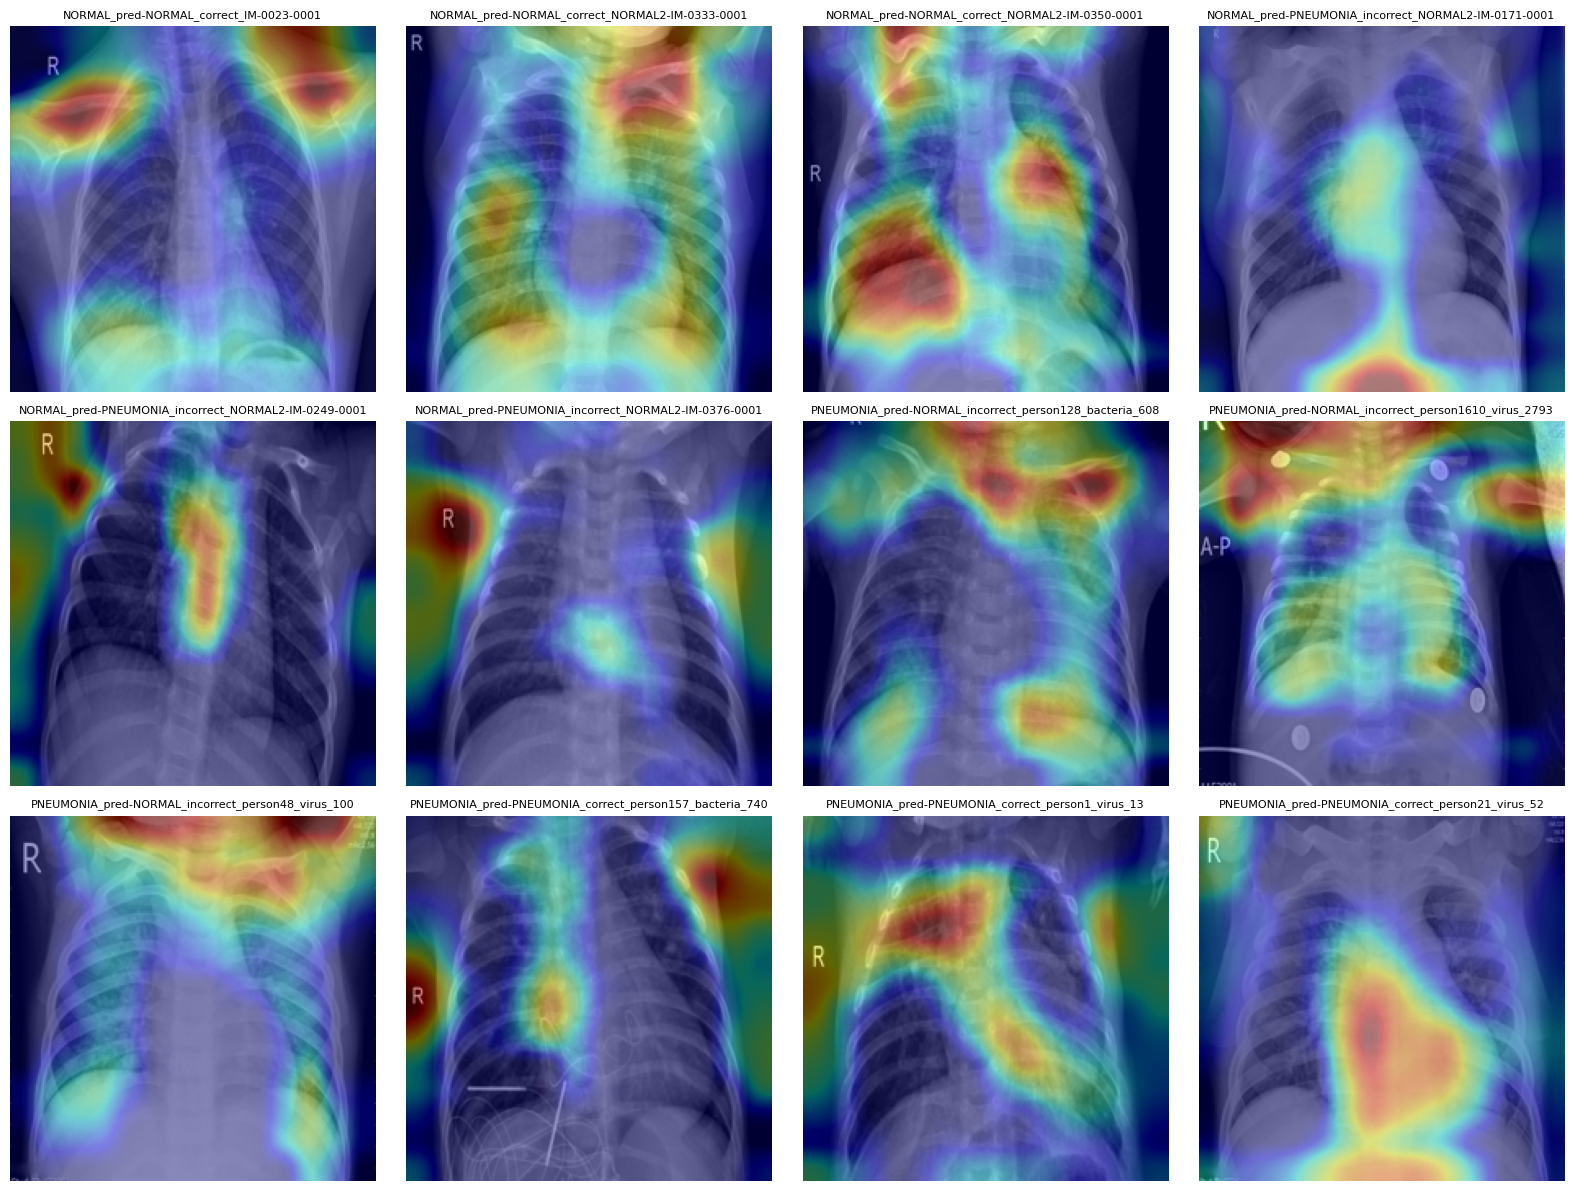

In [ ]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

paths = sorted(glob.glob("results/seed_42/gradcam/*.png"))
n = len(paths)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p))
    ax.set_title(Path(p).stem, fontsize=8)
    ax.axis("off")
for ax in axes[len(paths):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 6: Download results

Zips `results/` (model checkpoints, per-seed metrics, Grad-CAM overlays,
the aggregated `eval_summary.json`) for download.

In [ ]:
!zip -qr results.zip results
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 7: Ablation study -- fine-tuning and corner-masking (COMPLETE)

All four variants below are now confirmed at 3 seeds (see README's
"Ablation study" section for the full writeup). Headline finding: **nothing
beat the simple frozen, unmasked baseline** once properly confirmed --

- **Fine-tuning** (`binary_pneumonia_finetune.yaml`): confirmed *twice*
  (two independent 3-seed runs, 86.4% +/- 3.0% and 86.2% +/- 2.2%) --
  same mean as baseline, 2-4x the variance. A single-seed check had
  suggested a clear win (89.1%); that was an outlier.
- **Corner-masking** (`binary_pneumonia_masked.yaml`): 84.9% +/- 2.2%,
  about 1.5-2 points below baseline. A single-seed check had suggested no
  effect (86.9%, matching baseline); *that* turned out to be wrong too --
  in the opposite direction from the fine-tuning case. Likely explanation:
  the 12%-corner mask clips some genuine anatomy near the image edges, not
  just the "R" marker.
- **Fine-tune + masked combined** (`binary_pneumonia_finetune_masked.yaml`):
  85.5% +/- 5.6% -- the least stable variant by far (one seed as low as
  79.2%).

The cells below are kept for reproduction. Each variant's cell downloads a
zip of just that variant's results right after it finishes -- useful since
Colab free-tier runtimes can disconnect mid-run without warning.

**Requires Steps 0-2 already run in this session** (so `/content/chest_xray`
and `pneumonia_cnn/` exist) -- if you're in a fresh Colab session, run those
first.

In [ ]:
%%writefile configs/binary_pneumonia_finetune.yaml
# Ablation variant: same as binary_pneumonia.yaml, but phase-2 fine-tunes
# the top 4 VGG16 layers (~ the last conv block) for 6 more epochs at a low
# LR, instead of leaving the whole backbone frozen. Tests whether the
# frozen-backbone baseline (86.9% +/- 0.8%, see README) was leaving
# accuracy on the table.
#
# CONFIRMED at 3 seeds (see README's "Ablation study" section): 86.4% +/-
# 3.0% -- essentially the same mean as baseline but ~4x the variance. A
# single-seed check initially suggested a clear win (89.1%); the full
# 3-seed run showed that was an outlier, not a real effect. Fine-tuning
# does not reliably improve on the frozen baseline for this dataset/setup.

class_names: ["NORMAL", "PNEUMONIA"]
data_root: "/content/chest_xray"

img_size: 224
backbone: "vgg16"
dense_units: 64
dropout: 0.5

batch_size: 32
epochs: 15
init_lr: 0.001
val_fraction: 0.10
seeds: [42, 43, 44]
use_class_weights: true
early_stopping_patience: 4

fine_tune: true
fine_tune_layers: 4
fine_tune_epochs: 6
fine_tune_lr: 0.00001

mask_corners: false

results_dir: "results_finetune"


Writing configs/binary_pneumonia_finetune.yaml


In [ ]:
%%writefile configs/binary_pneumonia_masked.yaml
# Ablation variant: same as binary_pneumonia.yaml (frozen backbone, no
# fine-tuning), but masks a 12%-of-image-size square out of all 4 corners
# of every image before it reaches the model -- removing the printed
# laterality marker (e.g. the "R" marker Grad-CAM found the baseline model
# attending to) from consideration entirely.
#
# CONFIRMED at 3 seeds (see README's "Ablation study" section): 84.9% +/-
# 2.2%, roughly 1.5-2 points below the baseline's pooled ~86.6% mean. A
# single-seed check initially suggested no effect (86.9%, matching
# baseline) -- that turned out to be wrong. The likely explanation isn't
# that the model specifically needs the marker text, but that the 12%
# corner mask also clips some genuine anatomy near the image edges, so
# removing it costs a modest amount of real signal along with the marker.

class_names: ["NORMAL", "PNEUMONIA"]
data_root: "/content/chest_xray"

img_size: 224
backbone: "vgg16"
dense_units: 64
dropout: 0.5

batch_size: 32
epochs: 15
init_lr: 0.001
val_fraction: 0.10
seeds: [42, 43, 44]
use_class_weights: true
early_stopping_patience: 4

fine_tune: false

mask_corners: true
mask_corner_frac: 0.12

results_dir: "results_masked"


Writing configs/binary_pneumonia_masked.yaml


In [ ]:
%%writefile configs/binary_pneumonia_finetune_masked.yaml
# Ablation variant: both fine-tuning AND corner-masking together -- the
# "best of both" combination, completing the 2x2 grid against the baseline
# (frozen/unmasked), binary_pneumonia_finetune.yaml (fine-tuned/unmasked),
# and binary_pneumonia_masked.yaml (frozen/masked).
#
# CONFIRMED at 3 seeds (see README's "Ablation study" section): 85.5% +/-
# 5.6% -- by far the least stable variant of the four (one seed as low as
# 79.2%, a 10.6-point spread across 3 seeds). Inherits fine-tuning's
# instability and stacks the masked variant's modest accuracy cost on top.
# Not recommended.

class_names: ["NORMAL", "PNEUMONIA"]
data_root: "/content/chest_xray"

img_size: 224
backbone: "vgg16"
dense_units: 64
dropout: 0.5

batch_size: 32
epochs: 15
init_lr: 0.001
val_fraction: 0.10
seeds: [42, 43, 44]
use_class_weights: true
early_stopping_patience: 4

fine_tune: true
fine_tune_layers: 4
fine_tune_epochs: 6
fine_tune_lr: 0.00001

mask_corners: true
mask_corner_frac: 0.12

results_dir: "results_finetune_masked"


Writing configs/binary_pneumonia_finetune_masked.yaml


### 7a: Fine-tune only (unmasked) -- CONFIRMED, 3 seeds, 86.4% +/- 3.0% (and 86.2% +/- 2.2% on replication)

Already run twice and recorded in the README -- rerun only if you want to
reproduce it again. Expect roughly 45-75 minutes for all 3 seeds (phase 1 +
6 fine-tune epochs each).

In [ ]:
!cd /content && python -m pneumonia_cnn.train --config configs/binary_pneumonia_finetune.yaml
!cd /content && python -m pneumonia_cnn.evaluate --config configs/binary_pneumonia_finetune.yaml

2026-07-17 22:05:30.735036: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

=== Training seed 42 ===
2026-07-17 22:05:35.266362: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784325935.267910   13914 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Epoch 1/15
2026-07-17 22:05:40.929653: I external/local_xla/xla/service/service.cc:163] XLA service 0x78f2f400fc40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-17 22:

In [ ]:
!zip -qr results_finetune.zip results_finetune
from google.colab import files
files.download("results_finetune.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7b: Corner-masking only (frozen backbone) -- CONFIRMED, 3 seeds, 84.9% +/- 2.2%

Already run and recorded in the README -- rerun only if you want to
reproduce it. Expect roughly 15-30 minutes for all 3 seeds.

In [ ]:
!cd /content && python -m pneumonia_cnn.train --config configs/binary_pneumonia_masked.yaml --seeds 42 43 44
!cd /content && python -m pneumonia_cnn.evaluate --config configs/binary_pneumonia_masked.yaml --seeds 42 43 44

2026-07-17 23:12:00.700545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

=== Training seed 42 ===
2026-07-17 23:12:06.110455: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784329926.111938   32413 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Epoch 1/15
2026-07-17 23:12:11.033664: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c9c1400dec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-17 23:

In [ ]:
!zip -qr results_masked.zip results_masked
from google.colab import files
files.download("results_masked.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 7c: Fine-tune + corner-masking combined -- CONFIRMED, 3 seeds, 85.5% +/- 5.6%

Already run and recorded in the README (least stable variant of the four)
-- rerun only if you want to reproduce it. Expect roughly 45-75 minutes for
all 3 seeds.

In [ ]:
!cd /content && python -m pneumonia_cnn.train --config configs/binary_pneumonia_finetune_masked.yaml --seeds 42 43 44
!cd /content && python -m pneumonia_cnn.evaluate --config configs/binary_pneumonia_finetune_masked.yaml --seeds 42 43 44

2026-07-17 23:54:44.678786: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

=== Training seed 42 ===
2026-07-17 23:54:49.496471: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784332489.498045   44149 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Epoch 1/15
2026-07-17 23:54:54.834899: I external/local_xla/xla/service/service.cc:163] XLA service 0x7acc5c00dd60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-07-17 23:

In [ ]:
!zip -qr results_finetune_masked.zip results_finetune_masked
from google.colab import files
files.download("results_finetune_masked.zip")

### 7d: Compare all four variants

Prefers live `eval_summary.json` files from this session if present, and
falls back to the confirmed numbers recorded in the README otherwise (so
this cell is useful for a quick reference table even in a fresh session
where nothing has been retrained).

In [ ]:
import json
from pathlib import Path

# Confirmed results from the README's "Ablation study" section -- used as a
# fallback when this session doesn't have live eval_summary.json files.
KNOWN_RESULTS = {
    "baseline": {"label": "baseline (frozen, unmasked)", "accuracy_mean": 0.8691, "accuracy_std": 0.0079, "n_seeds": 3},
    "results_finetune": {"label": "fine-tune only", "accuracy_mean": 0.8622, "accuracy_std": 0.0216, "n_seeds": 3},
    "results_masked": {"label": "corner-masked only", "accuracy_mean": 0.8488, "accuracy_std": 0.0216, "n_seeds": 3},
    "results_finetune_masked": {"label": "fine-tune + masked", "accuracy_mean": 0.8547, "accuracy_std": 0.0557, "n_seeds": 3},
}

order = ["baseline", "results_finetune", "results_masked", "results_finetune_masked"]
rows = []
for key in order:
    fallback = KNOWN_RESULTS[key]
    path = Path(key) / "eval_summary.json" if key != "baseline" else Path("results") / "eval_summary.json"
    if path.exists():
        with open(path) as f:
            s = json.load(f)
        rows.append({"label": fallback["label"], "accuracy_mean": s["accuracy_mean"], "accuracy_std": s["accuracy_std"], "n_seeds": s["n_seeds"], "source": "live"})
    else:
        rows.append({"label": fallback["label"], "accuracy_mean": fallback["accuracy_mean"], "accuracy_std": fallback["accuracy_std"], "n_seeds": fallback["n_seeds"], "source": "README"})

print("{:<28} {:>14} {:>6} {:>8}".format("Variant", "Accuracy", "Seeds", "Source"))
for r in rows:
    acc = "{:.1f}% +/- {:.1f}".format(r["accuracy_mean"] * 100, r["accuracy_std"] * 100)
    print("{:<28} {:>14} {:>6} {:>8}".format(r["label"], acc, r["n_seeds"], r["source"]))

Variant                            Accuracy  Seeds   Source
baseline (frozen, unmasked)   86.9% +/- 0.8      3   README
fine-tune only                86.2% +/- 2.2      3   README
corner-masked only            84.9% +/- 2.2      3   README
fine-tune + masked            85.5% +/- 5.6      3   README


## Next steps (not run in this notebook)

- **Multiclass** (Normal/Bacterial/Viral/COVID): see
  `configs/multiclass_template.yaml` in the repo for the documented data-prep
  steps needed, then this same pipeline (data.py/model.py/train.py/
  evaluate.py/gradcam.py) runs unchanged.
- **Federated learning**: see `pneumonia_cnn/federated/partition.py` for the
  scaffolded interface and research design (simulating non-IID hospital
  clients, FedAvg via Flower, comparing to this notebook's centralized
  baseline).
- **Cross-institution generalization**: evaluate this trained model
  (`results/seed_*/model.keras`) on a *different* source dataset (e.g. RSNA
  Pneumonia Detection Challenge) without retraining, to test whether
  accuracy holds up outside the Guangzhou single-center source data.
